## Imports

In [12]:
from __future__ import annotations

import os
import copy
import random
import itertools
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from scipy.stats import randint, uniform

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, train_test_split, GridSearchCV, RandomizedSearchCV, ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss, log_loss

import moexalgo
from moexalgo import Ticker
import moexalgo.engines.currency
from moexalgo import Market

from src.market_ml.preprocessing import _download_feature, _usdrub, _stock, _concat, rolling_zscore, rolling_beta, _basic_features, _context_features, _flow_trades, _regime_features, get_feature_groups,  build_feature_list, _correlation
from src.market_ml.backtest import backtest_probs, print_bt_report, plot_bt, confidence_report
from src.market_ml.train_utils import eval, best_threshold, fearure_importance
from src.market_ml.dataset import make_target, train_test_valid_split, walk_forward_split

In [13]:
SEED = 42
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
import warnings
warnings.filterwarnings("ignore")

## Functions

In [14]:
def calibrate_probs(valid_probs, y_valid, test_probs, method='platt'):
    valid_probs = np.asarray(valid_probs, dtype=float)
    test_probs = np.asarray(test_probs, dtype=float)
    y_valid = np.asarray(y_valid, dtype=int)

    if len(np.unique(y_valid)) < 2:
        p = float(y_valid.mean())
        return np.full(len(test_probs), p, dtype=float)

    if method == 'platt':
        calibrator = LogisticRegression()
        calibrator.fit(valid_probs.reshape(-1, 1), y_valid)
        cal_probs = calibrator.predict_proba(test_probs.reshape(-1, 1))[:, 1]
    else:
        calibrator = IsotonicRegression(out_of_bounds='clip')
        calibrator.fit(valid_probs, y_valid)
        cal_probs = calibrator.predict(test_probs)

    return np.clip(cal_probs, 1e-6, 1 - 1e-6)

In [15]:
def preprocessing(
    ticker,
    start_date, 
    end_date, 
    period,
    valid_size,
    test_size,
    threshold
):
    imoex = _download_feature('IMOEX', start_date=start_date, end_date=end_date, period=period)
    oilgas = _download_feature('MOEXOG', start_date=start_date, end_date=end_date, period=period)
    rtsi = _download_feature('RTSI', start_date=start_date, end_date=end_date, period=period)
    metal = _download_feature('MOEXMM', start_date=start_date, end_date=end_date, period=period)
    finance = _download_feature('MOEXFN', start_date=start_date, end_date=end_date, period=period)
    goverment_obligations = _download_feature('RGBITR', start_date=start_date, end_date=end_date, period=period)
    usdrub = _usdrub(start_date=start_date, end_date=end_date, period=period)
    stock = _stock(ticker=ticker, start_date=start_date, end_date=end_date, period=period)
    concat = _concat(stock, imoex, usdrub, oilgas, rtsi, metal, finance, goverment_obligations)

    lag_steps = [1, 2, 3, 5]
    mom_windows = [3, 5, 10, 20]
    vol_windows = [5, 10, 20]

    context_tickers = ['imoex', 'usdrub', 'moexog', 'rtsi', 'moexmm', 'moexfn', 'rgbitr']

    data = _basic_features(data=concat)
    data = _context_features(data=data, lag_steps=lag_steps, mom_windows=mom_windows, vol_windows=vol_windows, context_tickers=context_tickers)
    data = _flow_trades(data=data, lag_steps=lag_steps, mom_windows=mom_windows, vol_windows=vol_windows)
    data = _regime_features(data=data)

    features_list = build_feature_list(context_tickers=context_tickers, lag_steps=lag_steps, mom_windows=mom_windows, vol_windows=vol_windows)
    features_final = _correlation(data=data, features=features_list, threshold=threshold, test_size=test_size, valid_size=valid_size)
    
    return data, features_final

In [16]:
data, features_final = preprocessing(
    ticker='SBER',
    start_date='2022-01-01',
    end_date='2026-03-22',
    period='1d',
    valid_size=252,
    test_size=252//3,
    threshold=0.995
)

потеряно 81 - осталось 1049


In [17]:
data = make_target(data=data, horizont=1)

## Learning

In [18]:
best_cat_params = {'bagging_temperature': np.float64(1.554911608578311), 
                   'border_count': 100, 
                   'depth': 4, 
                   'l2_leaf_reg': np.float64(7.4716845866950345), 
                   'learning_rate': np.float64(0.01979131298383819), 
                   'random_strength': np.float64(2.806217129238506)}

In [19]:
result = []

for fold in walk_forward_split(
    data=data,
    features_final=features_final,
    train_size=252*2,
    valid_size=252//2,
    test_size=252//2,
    step_size=21*3,
    gap=1
):
    X_train = fold.X_train
    y_train = fold.y_train
    X_valid = fold.X_valid
    y_valid = fold.y_valid
    X_test = fold.X_test
    y_test = fold.y_test

    model = CatBoostClassifier(
        iterations=5000,
        loss_function="Logloss",
        eval_metric="Accuracy",
        random_seed=42,
        verbose=0,
        auto_class_weights="Balanced",
        bootstrap_type="Bayesian",
        has_time=True,
        **best_cat_params
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
        early_stopping_rounds=200
    )

    valid_auc, valid_acc, valid_probs_raw = eval(model, X_valid, y_valid)
    test_auc, test_acc, test_probs_raw = eval(model, X_test, y_test)

    test_probs_raw = np.clip(test_probs_raw, 1e-6, 1 - 1e-6)
    test_probs_cal = calibrate_probs(
        valid_probs=valid_probs_raw,
        y_valid=y_valid,
        test_probs=test_probs_raw,
        method='platt'
    )

    result.append({
        'fold': fold.fold,
        'valid_auc': valid_auc,
        'valid_acc': valid_acc,
        'test_auc_raw': test_auc,
        'test_acc_raw': test_acc,
        'test_auc_cal': roc_auc_score(y_test, test_probs_cal),
        'test_brier_raw': brier_score_loss(y_test, test_probs_raw),
        'test_logloss_raw': log_loss(y_test, test_probs_raw),
        'test_brier_cal': brier_score_loss(y_test, test_probs_cal),
        'test_logloss_cal': log_loss(y_test, test_probs_cal),
        'best_iter': model.get_best_iteration()
    })

result = pd.DataFrame(result)
result

,fold,valid_auc,valid_acc,test_auc_raw,test_acc_raw,test_auc_cal,test_brier_raw,test_logloss_raw,test_brier_cal,test_logloss_cal,best_iter
0,0,0.566456,0.587302,0.510333,0.523810,0.510333,0.250056,0.693262,0.250498,0.694144,60
1,1,0.538323,0.539683,0.530736,0.531746,0.530736,0.249687,0.692521,0.259640,0.712596,12
2,2,0.586129,0.619048,0.502394,0.547619,0.502394,0.250701,0.694581,0.250214,0.693576,98
3,3,0.554040,0.555556,0.600302,0.563492,0.600302,0.245762,0.684632,0.249950,0.693046,92
4,4,0.568405,0.563492,0.577778,0.539683,0.577778,0.245746,0.684584,0.249721,0.692588,130


In [20]:
result[['valid_auc', 'valid_acc', 'test_auc_raw', 'test_acc_raw', 'test_auc_cal', 'test_brier_raw', 'test_logloss_raw', 'test_brier_cal', 'test_logloss_cal']].mean().to_frame('mean').T

,valid_auc,valid_acc,test_auc_raw,test_acc_raw,test_auc_cal,test_brier_raw,test_logloss_raw,test_brier_cal,test_logloss_cal
mean,0.562671,0.573016,0.544309,0.54127,0.544309,0.24839,0.689916,0.252005,0.69719


In [21]:
X_train, y_train, X_valid, y_valid, X_test, y_test, train, valid, test = train_test_valid_split(data=data, features_final=features_final, test_size=252, valid_size=252)
# X_train, y_train, X_valid, y_valid, X_test, y_test, train, valid, test = train_test_valid_split(data=data, features_final=top_15_features, test_size=252//3, valid_size=252)

cat = CatBoostClassifier(
    iterations=5000,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=200,
    auto_class_weights="Balanced",
    bootstrap_type="Bayesian",
    has_time=True,
    **best_cat_params
)

cat.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
    early_stopping_rounds=200
)

train_auc, train_acc, train_probs_cat = eval(cat, X_train, y_train)
valid_auc, valid_acc, valid_probs_cat = eval(cat, X_valid, y_valid)
test_auc, test_acc, test_probs_cat = eval(cat, X_test, y_test)

print(f"train roc_auc: {train_auc:.4f} | train accuracy: {train_acc:.4f}")
print(f"valid roc_auc: {valid_auc:.4f} | valid accuracy: {valid_acc:.4f}")
print(f"test  roc_auc: {test_auc:.4f} | test  accuracy: {test_acc:.4f}")
print("best_iteration:", cat.get_best_iteration())

0:	learn: 0.5570660	test: 0.5373754	best: 0.5373754 (0)	total: 10.1ms	remaining: 50.3s
200:	learn: 0.8590510	test: 0.5031185	best: 0.5373754 (0)	total: 1.51s	remaining: 36.1s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.5373754129
bestIteration = 0

Shrink model to first 1 iterations.
train roc_auc: 0.5797 | train accuracy: 0.5395
valid roc_auc: 0.5191 | valid accuracy: 0.5238
test  roc_auc: 0.5143 | test  accuracy: 0.5000
best_iteration: 0


In [22]:
threshold, acc = best_threshold(y_valid, valid_probs_cat)
print(threshold, acc)

0.5040404040404041 0.5198412698412699


total_return:    -0.0386
cagr:            -0.0386
sharpe:          -0.0958
sortino:         -0.1289
vol:             0.2009
max_drawdown:    -0.1865
trades:          35
turnover_mean:   0.2738
exposure:        1.0000
hit_rate:        0.4921
active_hit_rate: 0.4921


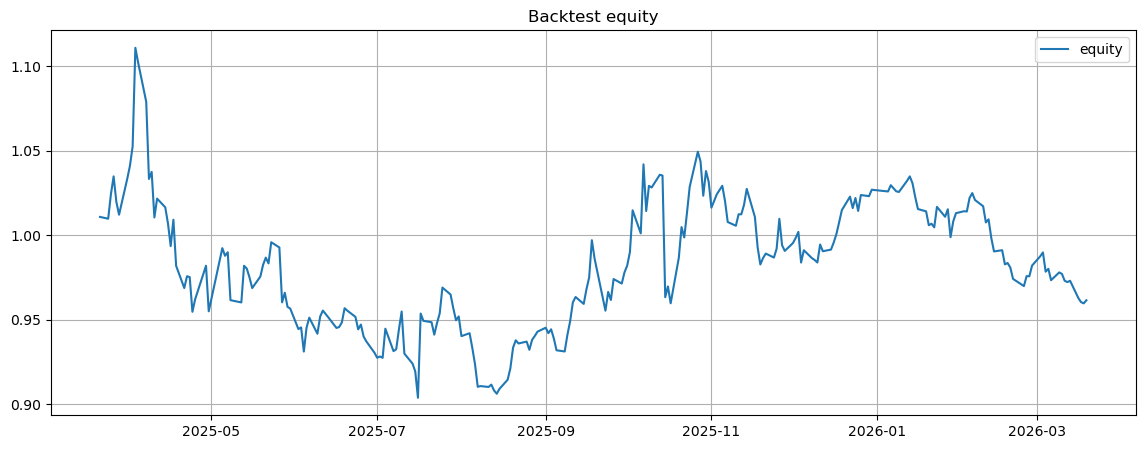

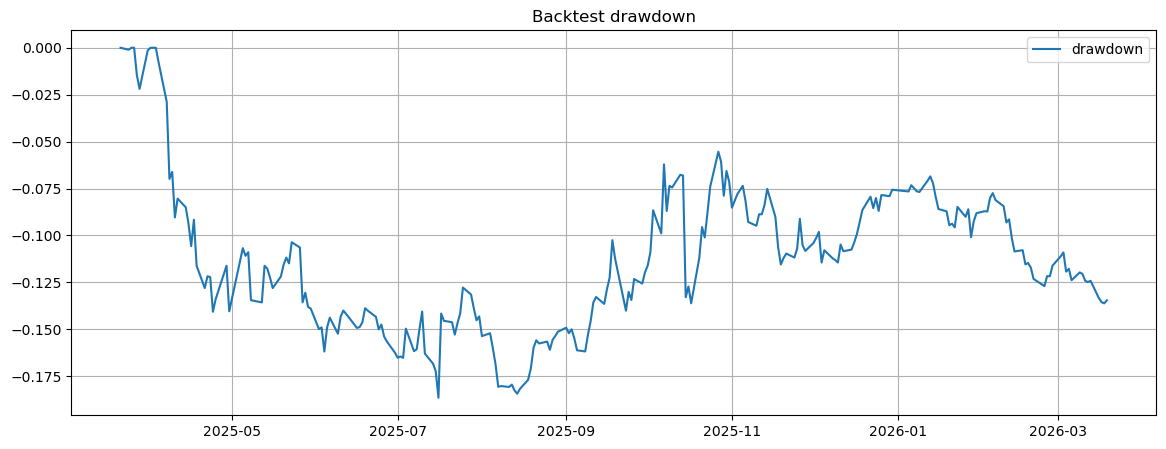

In [23]:
cat_bt = backtest_probs(
    proba_long=test_probs_cat,
    fwd_ret=test['fwd_ret'].values,
    date=test['date'].values,
    lower=threshold - 1e-9,
    upper=threshold + 1e-9,
    cost_bps=10,
    ret_type='log'
)

print_bt_report(cat_bt)
# cat_bt['yearly']
plot_bt(cat_bt)

In [24]:
df, summ = fearure_importance(cat, features_final, n=15)
print(summ)
df

100.0


,feature,importance
62,moexog_mom3,33.955999
46,moexfn_ret_lag1,24.946346
122,ts_close_to_vwap_lag5,21.603884
164,ts_vwap_mom_ma20,19.493771
2,r10,0.000000
5,r1_vol20,0.000000
6,range,0.000000
3,r20,0.000000
4,r1_vol5,0.000000
9,upper_wick,0.000000


In [ ]:
top_15_features = list(df['feature'].values)